# Notebook 9 — MTDA Multi-Target Extension

Implements the multi-target domain adaptation (MTDA) extension from the plan:
- one labelled source domain (C-MAPSS FD001)
- multiple unlabelled target domains (AI4I, Haas VF-1, Lathe ADXL335, Pump CIRA)
- multi-class domain discriminator with convergence target near $\log(N_{domains})$.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from src.models.private_extractors import build_hda_extractor_registry

np.random.seed(42)
tf.random.set_seed(42)

WINDOW_SIZE = 30
MAX_RUL = 125
FEATURE_DIM = 64

DOMAIN_REGISTRY = {
    'source_cmapss_fd001': 24,
    'target_ai4i': 5,
    'target_haas_vf1': 20,
    'target_lathe_adxl': 3,
    'target_pump_cira': 8,
}
N_DOMAINS = len(DOMAIN_REGISTRY)

print('MTDA Configuration:')
print(f'  Source domains: 1')
print(f'  Target domains: {N_DOMAINS - 1}')
print(f'  Domain discriminator classes: {N_DOMAINS}')
print(f'  Shared feature dim: {FEATURE_DIM}')
for name, sensors in DOMAIN_REGISTRY.items():
    role = 'SOURCE' if 'source' in name else 'TARGET'
    print(f'  [{role}] {name:<28} ({sensors} sensors)')

extractor_registry = build_hda_extractor_registry(DOMAIN_REGISTRY, WINDOW_SIZE, FEATURE_DIM)
print(f'\nBuilt extractor registry with {len(extractor_registry)} domain extractors.')

MTDA Configuration:
  Source domains: 1
  Target domains: 4
  Domain discriminator classes: 5
  Shared feature dim: 64
  [SOURCE] source_cmapss_fd001          (24 sensors)
  [TARGET] target_ai4i                  (5 sensors)
  [TARGET] target_haas_vf1              (20 sensors)
  [TARGET] target_lathe_adxl            (3 sensors)
  [TARGET] target_pump_cira             (8 sensors)
  ✅ Private extractor: source_cmapss_fd001 (24 sensors → 64 features)
  ✅ Private extractor: target_ai4i (5 sensors → 64 features)
  ✅ Private extractor: target_haas_vf1 (20 sensors → 64 features)
  ✅ Private extractor: target_lathe_adxl (3 sensors → 64 features)
  ✅ Private extractor: target_pump_cira (8 sensors → 64 features)

Built extractor registry with 5 domain extractors.


In [2]:
from tensorflow.keras import layers, Model, Input

def build_multiclass_domain_discriminator(feature_dim: int = 64,
                                          n_domains: int = 5,
                                          hidden_units=None,
                                          dropout_rate: float = 0.2) -> Model:
    if hidden_units is None:
        hidden_units = [128, 64]

    inp = Input(shape=(feature_dim,), name='disc_features')
    x = inp
    for i, units in enumerate(hidden_units):
        x = layers.Dense(units, activation='relu', name=f'disc_hidden_{i+1}')(x)
        x = layers.Dropout(dropout_rate, name=f'disc_drop_{i+1}')(x)
    out = layers.Dense(n_domains, activation='softmax', name='domain_probabilities')(x)
    return Model(inputs=inp, outputs=out, name=f'MultiClass_Domain_Discriminator_{n_domains}way')

disc = build_multiclass_domain_discriminator(feature_dim=FEATURE_DIM, n_domains=N_DOMAINS)
disc.summary()

print(f'\nConvergence target: cross-entropy ~= log({N_DOMAINS}) = {np.log(N_DOMAINS):.3f}')

Model: "MultiClass_Domain_Discriminator_5way"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ disc_features (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_hidden_1 (Dense)           │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_drop_1 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_hidden_2 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disc_drop_2 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ domain_probabilities (Dense)    │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,901 (66.02 KB)

 Trainable params: 16,901 (66.02 KB)

 Non-trainable params: 0 (0.00 B)


Convergence target: cross-entropy ~= log(5) = 1.609


In [3]:
from scipy.signal import decimate


def load_haas_vf1_cut(filepath: str,
                      vib_channels=None,
                      cur_channels=None,
                      vib_sample_rate: int = 25000,
                      cur_sample_rate: int = 500,
                      window_size_ms: float = 100.0) -> np.ndarray:
    if vib_channels is None:
        vib_channels = [f'vib_ch{i}' for i in range(1, 4)]
    if cur_channels is None:
        cur_channels = [f'cur_ch{i}' for i in range(1, 4)]

    df = pd.read_csv(filepath)
    downsample_factor = max(1, vib_sample_rate // cur_sample_rate)
    window_samples = int(cur_sample_rate * window_size_ms / 1000)

    all_windows = []
    n_windows = len(df) // max(1, (downsample_factor * window_samples))

    for w in range(n_windows):
        lo_cur = w * window_samples
        hi_cur = lo_cur + window_samples
        lo_vib = lo_cur * downsample_factor
        hi_vib = hi_cur * downsample_factor

        feats = []
        for ch in vib_channels:
            if ch in df.columns:
                vib_raw = df[ch].values[lo_vib:hi_vib]
                vib_ds = decimate(vib_raw, q=downsample_factor, zero_phase=True) if len(vib_raw) >= downsample_factor and downsample_factor > 1 else vib_raw
                feats.extend([
                    np.max(np.abs(vib_ds)) if len(vib_ds) else 0.0,
                    np.sqrt(np.mean(vib_ds**2)) if len(vib_ds) else 0.0,
                    np.std(vib_ds) if len(vib_ds) else 0.0,
                ])

        for ch in cur_channels:
            if ch in df.columns:
                cur_raw = df[ch].values[lo_cur:hi_cur]
                feats.extend([
                    np.mean(cur_raw) if len(cur_raw) else 0.0,
                    np.sqrt(np.mean(cur_raw**2)) if len(cur_raw) else 0.0,
                    np.std(cur_raw) if len(cur_raw) else 0.0,
                ])

        if feats:
            all_windows.append(feats)

    return np.array(all_windows, dtype=np.float32)


print('Haas handler ready: load_haas_vf1_cut(filepath)')

Haas handler ready: load_haas_vf1_cut(filepath)


In [4]:
from scipy.stats import kurtosis as sp_kurt, skew as sp_skew


def load_lathe_adxl335(filepath: str,
                       cols=None,
                       sample_rate: int = 3000,
                       window_size: int = 30,
                       hop: int = 15):
    if cols is None:
        cols = ['ax', 'ay', 'az']

    df = pd.read_csv(filepath)
    data = df[cols].values.astype(np.float32)

    for c in range(data.shape[1]):
        rng = np.ptp(data[:, c]) + 1e-12
        data[:, c] = (data[:, c] - data[:, c].mean()) / (rng / 2)

    windows, times = [], []
    for start in range(0, len(data) - window_size, hop):
        windows.append(data[start:start + window_size])
        times.append(start / sample_rate)

    return np.array(windows, dtype=np.float32), np.array(times)


def diagnose_lathe_health_state(window: np.ndarray) -> dict:
    rms_all = np.sqrt(np.mean(window ** 2))
    kurt_all = np.mean([float(sp_kurt(window[:, axis])) for axis in range(3)])
    peak_all = np.max(np.abs(window))

    if kurt_all > 4.5:
        state, conf = 'Broken Tip (Impulsive)', min(1.0, (kurt_all - 4.5) / 5.0)
    elif rms_all > 0.35:
        state, conf = 'Worn Flank (High RMS)', min(1.0, (rms_all - 0.35) / 0.3)
    else:
        state, conf = 'Normal', max(0.0, 1.0 - rms_all / 0.35)

    return {
        'health_state': state,
        'rms': round(float(rms_all), 4),
        'kurtosis': round(float(kurt_all), 4),
        'peak': round(float(peak_all), 4),
        'confidence': round(float(conf), 3)
    }


print('Lathe handler ready: load_lathe_adxl335(filepath), diagnose_lathe_health_state(window)')

Lathe handler ready: load_lathe_adxl335(filepath), diagnose_lathe_health_state(window)


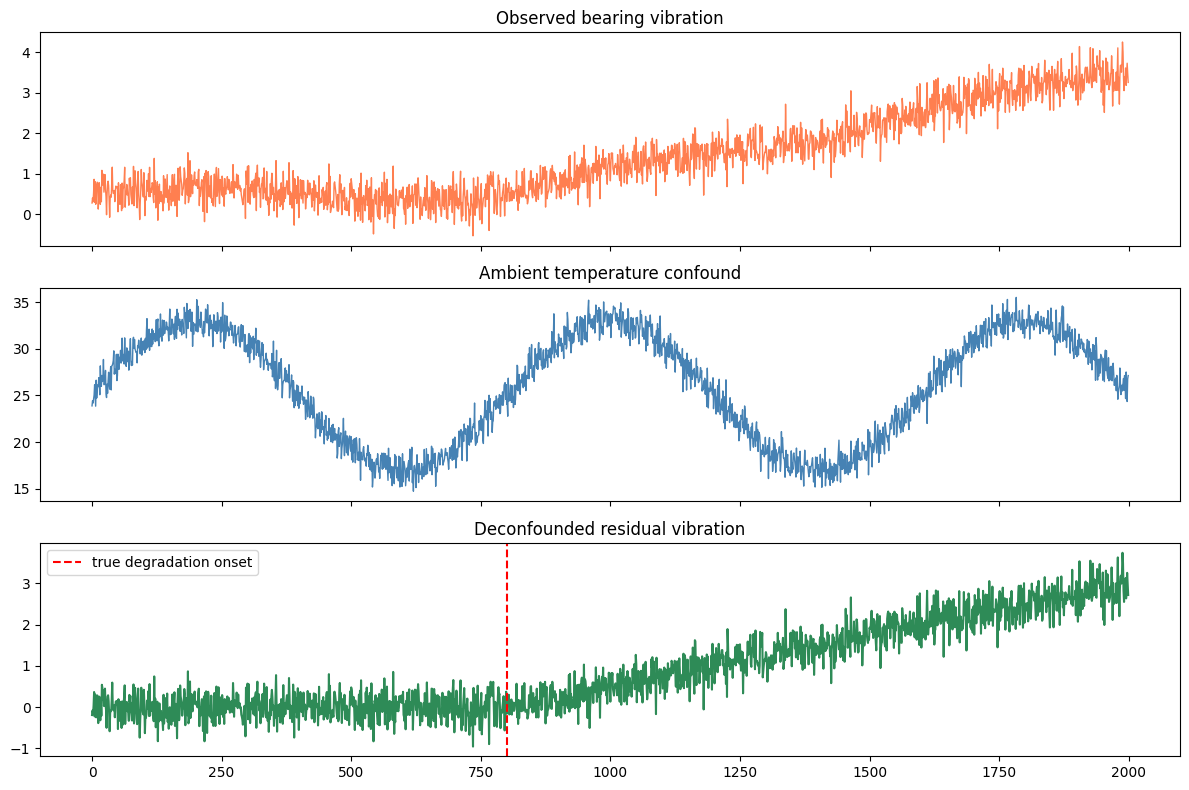

Pump deconfounding handlers ready.


In [6]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures


def fit_environmental_baseline(df: pd.DataFrame,
                               sensor_cols,
                               env_cols,
                               healthy_mask: pd.Series):
    poly = PolynomialFeatures(degree=2, include_bias=False)
    x_env = poly.fit_transform(df.loc[healthy_mask, env_cols].values)
    y_sens = df.loc[healthy_mask, sensor_cols].values
    model = Ridge(alpha=1.0)
    model.fit(x_env, y_sens)
    return model, poly


def deconfound_pump_sensors(df: pd.DataFrame,
                            sensor_cols,
                            env_cols,
                            healthy_mask: pd.Series) -> pd.DataFrame:
    baseline_model, poly = fit_environmental_baseline(df, sensor_cols, env_cols, healthy_mask)
    x_env_all = poly.transform(df[env_cols].values)
    y_pred = baseline_model.predict(x_env_all)

    if np.ndim(y_pred) == 1:
        y_pred = y_pred[:, np.newaxis]

    out = df.copy()
    for i, col in enumerate(sensor_cols):
        out[f'residual_{col}'] = out[col].values - y_pred[:, i]
    return out


# Synthetic deconfounding demonstration
n_samples = 2000
t = np.arange(n_samples)
ambient_temp = 25 + 8 * np.sin(2 * np.pi * t / 800) + np.random.normal(0, 1, n_samples)
atm_pressure = 1013 + 5 * np.cos(2 * np.pi * t / 1000) + np.random.normal(0, 2, n_samples)
degradation = np.where(t > 800, (t - 800) / 1200, 0)
bearing_vib = 0.5 * ambient_temp / 25 + 3.0 * degradation + np.random.normal(0, 0.3, n_samples)

pump_df = pd.DataFrame({
    'time': t,
    'ambient_temp': ambient_temp,
    'atm_pressure': atm_pressure,
    'bearing_vib': bearing_vib,
    'degradation': degradation,
})

healthy_mask = pump_df['degradation'] == 0
pump_deconfounded = deconfound_pump_sensors(
    pump_df,
    sensor_cols=['bearing_vib'],
    env_cols=['ambient_temp', 'atm_pressure'],
    healthy_mask=healthy_mask,
)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(pump_df['bearing_vib'], color='coral', lw=1)
axes[0].set_title('Observed bearing vibration')
axes[1].plot(pump_df['ambient_temp'], color='steelblue', lw=1)
axes[1].set_title('Ambient temperature confound')
axes[2].plot(pump_deconfounded['residual_bearing_vib'], color='seagreen', lw=1.5)
axes[2].axvline(800, color='red', ls='--', lw=1.5, label='true degradation onset')
axes[2].set_title('Deconfounded residual vibration')
axes[2].legend()
plt.tight_layout()
plt.show()

print('Pump deconfounding handlers ready.')

In [7]:
from src.models.grl import GradientReversalLayer


class MTDATrainer:
    def __init__(self,
                 feature_extractor: tf.keras.Model,
                 rul_regressor: tf.keras.Model,
                 domain_disc: tf.keras.Model,
                 grl_layer,
                 n_domains: int,
                 lr_reg: float = 1e-3,
                 lr_dom: float = 1e-3):
        self.feature_extractor = feature_extractor
        self.rul_regressor = rul_regressor
        self.domain_disc = domain_disc
        self.grl_layer = grl_layer
        self.n_domains = n_domains
        self.reg_opt = tf.keras.optimizers.Adam(lr_reg)
        self.dom_opt = tf.keras.optimizers.Adam(lr_dom)
        self.rul_loss_fn = tf.keras.losses.MeanSquaredError()
        self.dom_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    @tf.function
    def train_step(self, x_source, y_source, x_targets_list):
        batch_size = tf.shape(x_source)[0]

        x_all = tf.concat([x_source] + x_targets_list, axis=0)
        src_labels = tf.zeros(batch_size, dtype=tf.int32)
        tgt_labels = tf.concat([
            tf.fill([tf.shape(x_t)[0]], tf.cast(i + 1, tf.int32))
            for i, x_t in enumerate(x_targets_list)
        ], axis=0)
        domain_labels = tf.concat([src_labels, tgt_labels], axis=0)

        with tf.GradientTape(persistent=True) as tape:
            features_all = self.feature_extractor(x_all, training=True)
            features_src = features_all[:batch_size]

            rul_pred = self.rul_regressor(features_src, training=True)
            rul_loss = self.rul_loss_fn(tf.expand_dims(y_source, -1), rul_pred)

            grl_features = self.grl_layer(features_all)
            domain_logits = self.domain_disc(grl_features, training=True)
            dom_loss = self.dom_loss_fn(domain_labels, domain_logits)

            total_loss = rul_loss + dom_loss

        reg_vars = self.feature_extractor.trainable_variables + self.rul_regressor.trainable_variables
        grads_reg = tape.gradient(total_loss, reg_vars)
        self.reg_opt.apply_gradients(zip(grads_reg, reg_vars))

        grads_dom = tape.gradient(dom_loss, self.domain_disc.trainable_variables)
        self.dom_opt.apply_gradients(zip(grads_dom, self.domain_disc.trainable_variables))

        del tape
        return rul_loss, dom_loss


# Minimal functional smoke test
feature_extractor = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW_SIZE, FEATURE_DIM)),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(FEATURE_DIM, activation='relu')
], name='toy_feature_extractor')

rul_head = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(FEATURE_DIM,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
], name='toy_rul_head')

grl = GradientReversalLayer(alpha=1.0)
trainer = MTDATrainer(feature_extractor, rul_head, disc, grl, n_domains=N_DOMAINS)

batch = 16
x_src = tf.random.normal((batch, WINDOW_SIZE, FEATURE_DIM))
y_src = tf.random.uniform((batch,), minval=0.0, maxval=1.0)
x_targets = [tf.random.normal((batch, WINDOW_SIZE, FEATURE_DIM)) for _ in range(N_DOMAINS - 1)]

rul_l, dom_l = trainer.train_step(x_src, y_src, x_targets)
print(f'Smoke train_step ok: rul_loss={float(rul_l):.4f}, dom_loss={float(dom_l):.4f}, target log(N)={np.log(N_DOMAINS):.4f}')

Smoke train_step ok: rul_loss=0.5601, dom_loss=1.6149, target log(N)=1.6094
